In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')

#Data Read
file_path = 'heart_disease_uci.csv'
df = pd.read_csv(file_path, na_values='?')

Explained variance ratio for each component:
[0.16070886 0.11134419 0.09980574 0.07776093 0.07097462 0.06675368
 0.06011863 0.05672054 0.05277087 0.05079732 0.04287752 0.0358925
 0.03413815 0.02422678 0.02272053 0.01758477 0.00771847 0.00708589]




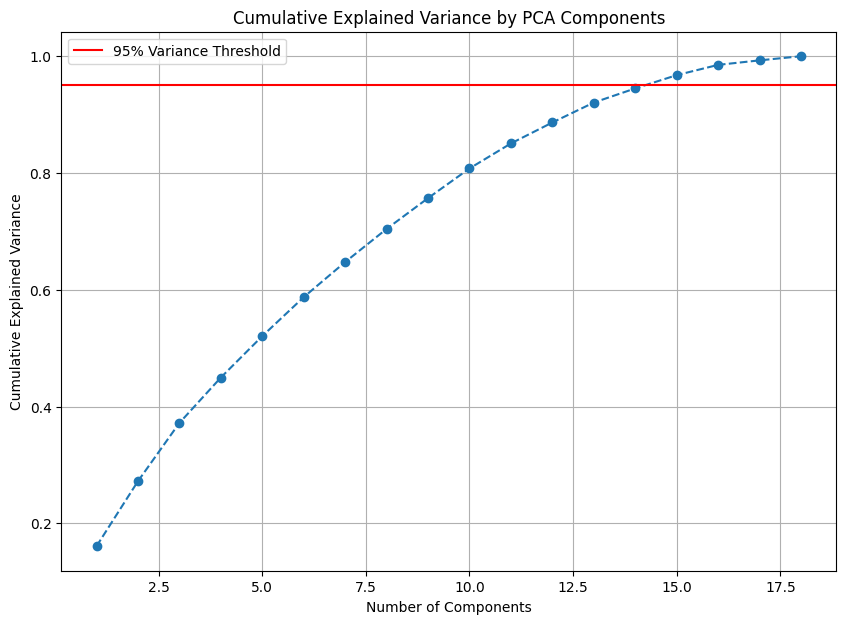

In [ ]:
#Handle Missing Values
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype == 'object':
            mode_value = df[col].mode()[0]
            df[col].fillna(mode_value, inplace=True)
        else:
            mean_value = df[col].mean()
            df[col].fillna(mean_value, inplace=True)

#Data Encoding
df_processed = df.drop(['id', 'dataset'], axis=1)
df_processed['num'] = (df_processed['num'] > 0).astype(int)
categorical_cols = df_processed.select_dtypes(include=['object']).columns
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

#Feature Scaling
X = df_processed.drop('num', axis=1)
y = df_processed['num']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

pca = PCA()
X_pca = pca.fit_transform(X_scaled_df)

#Cumulative explained variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

print("Explained variance ratio for each component:")
print(explained_variance_ratio)

#Visualize PCA Results
plt.figure(figsize=(10, 7))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Variance Threshold')
plt.legend()
plt.show()